# 02 · אמידת פרמטרים (Parameter Estimation)
**מבוסס על:** *Estimation in Information Fusion* — W. Dale Blair (GTRI), FUSION Boot Camp 2026, חלק א'.

### מתווה ההרצאה
❑ מבוא ❑ **אמידה פרמטרית (Parametric)** ❑ אמידת מצב סטוכסטית (Stochastic State) ❑ מעקב מטרות ❑ סיכום

### ההבחנה המרכזית
* **פרמטר** — כמות **קבועה בזמן** אך לא ידועה (למשל מיקום מטרה נייחת, הטיית חיישן). אומדים אותה ממדידות רועשות.
* **מצב (state)** — כמות ש**מתפתחת בזמן** (מיקום/מהירות/תאוצה), בד"כ קשורה במשוואות דיפרנציאליות → נושא מחברת 03.

מודל המדידה הכללי: $z_j = h(x) + w_j$, ומבקשים אומד $\hat{x}(Z_k)\approx x$ מתוך אוסף המדידות $Z_k=\{z_j\}_{j=1}^k$.

## א. משפחות האומדים

| אומד | הגדרה | מתי משתמשים |
|------|--------|-------------|
| **ML** (Maximum Likelihood) | $\hat{x}_{ML}=\arg\max_x p(Z\mid x)$ | אין מידע מוקדם על $x$ |
| **MAP** (Maximum A Posteriori) | $\hat{x}_{MAP}=\arg\max_x p(x\mid Z)\propto p(Z\mid x)\,p(x)$ | יש prior $p(x)$ |
| **MMSE** (Min. Mean Squared Error) | $\hat{x}_{MMSE}=E[x\mid Z]$ | מזעור $E\|x-\hat{x}\|^2$ |
| **LSE** (Least Squares) | $\hat{x}=\arg\min_x \sum_j (z_j-h_j(x))^2$ | אין מודל הסתברותי |
| **WLSE** (Weighted LSE) | $\hat{x}=\arg\min_x \sum_j (z_j-h_j(x))^2/\sigma_j^2$ | שונויות מדידה שונות |

עבור רעש גאוסיאני בלתי-תלוי, **ML ≡ WLSE** (משקלים = $1/\sigma_j^2$), וכאשר השונויות שוות **ML ≡ LSE**.

## ב. LSE למערכת לינארית
כאשר $z = Hx + w$ (batch של $N$ מדידות), פתרון הריבועים-הפחותים הוא:

$$\hat{x} = (H^TH)^{-1}H^Tz, \qquad P_{\hat{x}} = \sigma_w^2 (H^TH)^{-1}$$

ועבור WLSE עם מטריצת שונות $R$ של המדידות:

$$\hat{x} = (H^TR^{-1}H)^{-1}H^TR^{-1}z, \qquad P_{\hat{x}} = (H^TR^{-1}H)^{-1}$$

**דוגמת השקופית:** 11 מדידות של מטרה נייחת עם $\sigma_w=2$ m. כאן $h(x)=x$, כלומר $H=\mathbf{1}$, 
והפתרון מצטמצם ל**ממוצע**: $\hat{x}=\frac{1}{N}\sum z_j$ עם שונות $\sigma_w^2/N$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(1)

def lse_linear(H, z, R=None):
    """LSE / WLSE למערכת לינארית z = H x + w. R = מטריצת שונות (אופציונלי)."""
    H = np.atleast_2d(H); z = np.asarray(z, float).reshape(-1, 1)
    if R is None:
        G = np.linalg.inv(H.T @ H) @ H.T
        xhat = G @ z
        return xhat.ravel(), np.linalg.inv(H.T @ H)   # להכפיל ב-sigma^2 לקבלת P
    Ri = np.linalg.inv(R)
    P = np.linalg.inv(H.T @ Ri @ H)
    xhat = P @ H.T @ Ri @ z
    return xhat.ravel(), P

# דוגמת המטרה הנייחת (11 מדידות, sigma_w = 2)
true_x = 100.0; sigma_w = 2.0; N = 11
z = true_x + sigma_w * rng.standard_normal(N)
H = np.ones((N, 1))
xhat, M = lse_linear(H, z)
P = sigma_w**2 * M
print(f'אומד LSE = {xhat[0]:.3f} m   (אמת = {true_x})')
print(f'שונות האומד = {P[0,0]:.3f} = sigma_w^2/N = {sigma_w**2/N:.3f}')
print(f'סטיית תקן = {np.sqrt(P[0,0]):.3f} m')

אומד LSE = 100.414 m   (אמת = 100.0)
שונות האומד = 0.364 = sigma_w^2/N = 0.364
סטיית תקן = 0.603 m


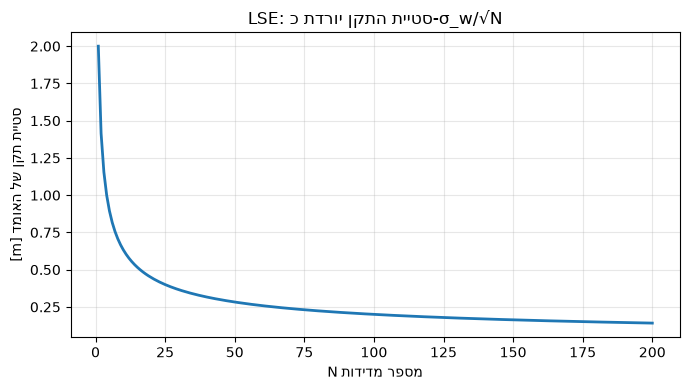

In [2]:
# התכנסות: סטיית התקן יורדת כ-1/sqrt(N)
Ns = np.arange(1, 201)
std_theory = sigma_w / np.sqrt(Ns)
plt.figure(figsize=(7,4))
plt.plot(Ns, std_theory, 'C0', lw=2)
plt.xlabel('מספר מדידות N'); plt.ylabel('סטיית תקן של האומד [m]')
plt.title('LSE: סטיית התקן יורדת כ-σ_w/√N'); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## ג. חסם Cramér–Rao התחתון (CRLB)
ה-CRLB הוא חסם תחתון על השונות של **כל** אומד חסר-הטיה:

$$\operatorname{Var}(\hat{x}) \ge \frac{1}{I(x)}, \qquad I(x) = -E\!\left[\frac{\partial^2 \ln p(Z\mid x)}{\partial x^2}\right]$$

כאשר $I(x)$ היא **מידע פישר (Fisher Information)**. אומד שמשיג את החסם נקרא *efficient*. 
עבור $N$ מדידות גאוסיאניות בלתי-תלויות של פרמטר נייח, $I(x)=N/\sigma_w^2$, ולכן 
$\operatorname{Var}(\hat{x})\ge \sigma_w^2/N$ — וה-LSE/ML משיג שוויון (efficient).

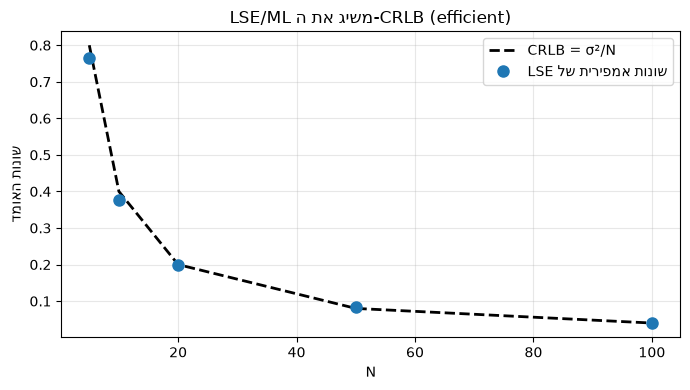

In [3]:
# אימות Monte-Carlo: האם LSE מגיע ל-CRLB?
sigma_w = 2.0
Ns = [5, 10, 20, 50, 100]
mc = 5000
emp_var, crlb = [], []
for N in Ns:
    ests = []
    for _ in range(mc):
        z = true_x + sigma_w*rng.standard_normal(N)
        ests.append(z.mean())
    emp_var.append(np.var(ests))
    crlb.append(sigma_w**2 / N)

plt.figure(figsize=(7,4))
plt.plot(Ns, crlb, 'k--', lw=2, label='CRLB = σ²/N')
plt.plot(Ns, emp_var, 'o', ms=8, label='שונות אמפירית של LSE')
plt.xlabel('N'); plt.ylabel('שונות האומד'); plt.legend(); plt.grid(alpha=.3)
plt.title('LSE/ML משיג את ה-CRLB (efficient)'); plt.tight_layout(); plt.show()

## ד. אמידת ML — דוגמה לא-לינארית
Blair מדגים אמד ML על מודל לא-לינארי בסגנון $z_j = \cos(2\pi w x) + w_j$. 
כאן ה-likelihood אינו קמור ויש לחפש את המקסימום נומרית (סריקה / אופטימיזציה).
להלן נשתמש במודל לא-לינארי פשוט יותר לאמידת **תדר** $f$ מתוך אות דגום: $z_j = \cos(2\pi f\, t_j) + w_j$.

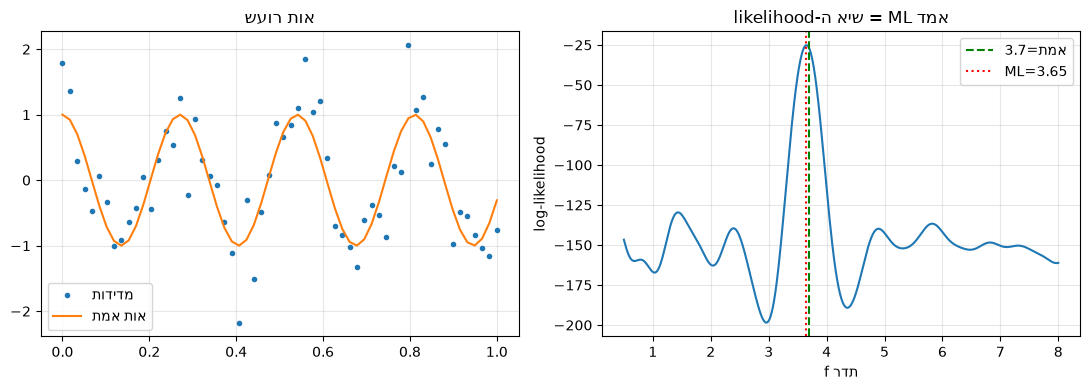

אומד ML של התדר = 3.652  (אמת = 3.7)


In [4]:
# ML לאמידת תדר ע"י סריקת ה-log-likelihood
f_true = 3.7; sigma = 0.5
t = np.linspace(0, 1, 60)
z = np.cos(2*np.pi*f_true*t) + sigma*rng.standard_normal(t.size)

f_grid = np.linspace(0.5, 8, 1500)
# log-likelihood גאוסיאני: -0.5/sigma^2 * sum (z - cos(2 pi f t))^2  (+const)
ll = np.array([-0.5/sigma**2 * np.sum((z - np.cos(2*np.pi*f*t))**2) for f in f_grid])
f_ml = f_grid[np.argmax(ll)]

fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(t, z, '.', label='מדידות'); ax[0].plot(t, np.cos(2*np.pi*f_true*t), label='אות אמת')
ax[0].set_title('אות רועש'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(f_grid, ll); ax[1].axvline(f_true, color='g', ls='--', label=f'אמת={f_true}')
ax[1].axvline(f_ml, color='r', ls=':', label=f'ML={f_ml:.2f}')
ax[1].set_xlabel('תדר f'); ax[1].set_ylabel('log-likelihood'); ax[1].set_title('אמד ML = שיא ה-likelihood')
ax[1].legend(); ax[1].grid(alpha=.3); plt.tight_layout(); plt.show()
print(f'אומד ML של התדר = {f_ml:.3f}  (אמת = {f_true})')

## ה. אמידת הטיית חיישן (Sensor Bias) ובעיית התצפיתיות
Blair מקדיש כמה שקופיות לאמידת **הטיה (bias)** של חיישן. הלקח המרכזי: עם חיישן יחיד, 
המיקום $x$ וההטיה $b$ **בלתי-נצפים בנפרד** — המדידה היא תמיד $z=x+b+w$, וכל חלוקה בין $x$ ל-$b$ 
מתאימה לאותם נתונים. המטריצה $H^TH$ נעשית סינגולרית ו"האומד אינו ניתן לחישוב".

**הפתרון:** הוספת מקור מידע נוסף (חיישן שני, או מטרת ייחוס/calibration שמיקומה ידוע) הופכת את הבעיה לנצפית — 
וזו בדיוק הנקודה שבה **fusion** נכנס: מיזוג מקורות פותר אי-תצפיתיות.

In [5]:
# הדגמה: חיישן יחיד -> H^T H סינגולרי (x ו-b בלתי נצפים בנפרד)
# מדידה: z = x + b + w. נעלמים: [x, b].
N = 10
H_single = np.hstack([np.ones((N,1)), np.ones((N,1))])  # שתי העמודות זהות!
print('דרגת H (חיישן יחיד):', np.linalg.matrix_rank(H_single), 'מתוך 2 -> סינגולרי, לא ניתן להפריד x ו-b')

# פתרון: מטרת כיול במיקום ידוע x0=0 (b לבדו נצפה) + מטרה לא ידועה
# חיישן מודד את מטרת הכיול ואת המטרה: z_cal = 0 + b + w ; z_tgt = x + b + w
x_true, b_true, sw = 50.0, 4.0, 1.0
m = 200
z_cal = 0 + b_true + sw*rng.standard_normal(m)
z_tgt = x_true + b_true + sw*rng.standard_normal(m)
# נעלמים theta=[x, b]; שתי משוואות: z_cal = b ; z_tgt = x + b
Hc = np.array([[0.,1.],[1.,1.]])
zc = np.array([z_cal.mean(), z_tgt.mean()])
theta, _ = lse_linear(Hc, zc, R=np.eye(2)*(sw**2/m))
print(f'עם מטרת כיול:  x̂ = {theta[0]:.2f} (אמת {x_true}),  b̂ = {theta[1]:.2f} (אמת {b_true})')
print('-> מקור מידע נוסף (fusion) הפך את הבעיה לנצפית.')

דרגת H (חיישן יחיד): 1 מתוך 2 -> סינגולרי, לא ניתן להפריד x ו-b
עם מטרת כיול:  x̂ = 50.00 (אמת 50.0),  b̂ = 3.90 (אמת 4.0)
-> מקור מידע נוסף (fusion) הפך את הבעיה לנצפית.


## סיכום
* **ML / MAP / MMSE / LSE / WLSE** — משפחת אומדים; תחת רעש גאוסיאני הם מתלכדים (ML≡WLSE, ושווה-שונות ⇒ ≡LSE).
* **LSE לינארי:** $\hat{x}=(H^TR^{-1}H)^{-1}H^TR^{-1}z$ עם שונות $(H^TR^{-1}H)^{-1}$.
* **CRLB** קובע את הרצפה לשונות; LSE/ML *efficient* עבור מטרה נייחת.
* **תצפיתיות:** הטיה ומיקום בלתי-נפרדים בחיישן יחיד — **fusion** של מקורות פותר זאת.

במחברת 03 נעבור מפרמטר **נייח** למצב ש**מתפתח בזמן** — וכך נגיע למסנן קלמן.